<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day08-ml-foundations-and-pytorch.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 8 — Machine Learning Foundations & Practical PyTorch, in code {.unnumbered}

This notebook follows the day's three parts:

1. **What learning from data means**: regression vs. classification on
   two real biological problems, and a tiny 3×3-pixel pattern problem
   used as a running toy example.
2. **Data and evaluation**: train/validation/test sets, evaluation
   metrics, cross-validation, class imbalance, and the biggest
   biology-specific trap, **homologous sequences leaking across the
   split**. We measure that effect on real data.
3. **From neurons to networks**: activation functions, softmax, and a
   real PyTorch `nn.Module` for subcellular localization. The network is
   defined and shape-checked here, but **not trained**. Day 9 trains it
   on the homology-aware split built in Part 2.

In [1]:
import re, os, shutil, subprocess, tempfile, io
import numpy as np
import requests
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support, roc_auc_score,
    roc_curve, matthews_corrcoef, mean_squared_error, r2_score,
)
from scipy.stats import pearsonr

torch.manual_seed(0)
np.random.seed(0)
FIGS = "../figs" if os.path.isdir("../figs") else "."   # save figures next to the book when run in the repo

# Part 1 — What does it mean to learn from data?

**Supervised learning** fits a model to labelled examples: inputs whose
correct answer is already known. **Unsupervised learning** looks for
structure in data without labels, for example clustering sequences into
families. Everything from Day 5 onward is supervised. Supervised problems
come in two kinds, depending on what the label is:

- **Regression**: the label is a *number*, e.g. a helix fraction, a
  melting temperature, an expression level or a binding affinity.
- **Classification**: the label is a *category*, e.g. a compartment,
  signal peptide yes/no, or helix/strand/coil.

Below are two real examples, one of each.

## A regression problem: helix fraction from composition

The same 55 PDB entries as the Day 6 lab, fetched live from EBI's PDBe
API. Here we use a single feature: the fraction of the sequence made up
of residues with a Chou-Fasman helix propensity of at least 1.1
(E, M, A, L, K, F, Q). The target is the real fraction of residues in
helices.

In [2]:
PDB_IDS = ['21XG', '38LJ', '9WRU', '9NVT', '9XZ9', '7ILS', '9RYL', '9TLR', '32TC', '13DZ', '9TCX', '9YBX', '9N2Y', '29OL', '9PNX', '9YMO', '9HWE', '9RPQ', '9RR6', '9W2A', '21LO', '9RK7', '9OU3', '9P39', '9T4I', '9VOM', '9W28', '9RFG', '9V5C', '9RQP', '9I4O', '9QWL', '9QYO', '9WM8', '9QRF', '9X6R', '9TZG', '9QGV', '9U97', '9YK5', '9IC9', '9XPD', '9DJF', '9DJR', '9NK4', '9NCE', '9I1B', '9RQQ', '7IPN', '9LCS', '9Z70', '9KZN', '9SI4', '9P45', '9FD0']
HELIX_FORMERS = "EMALKFQ"   # Chou-Fasman helix propensity >= 1.1

def fetch_helix_fraction(pdbid):
    lo = pdbid.lower()
    r = requests.get(f"https://www.ebi.ac.uk/pdbe/api/pdb/entry/molecules/{lo}", timeout=15)
    r.raise_for_status()
    mol = [m for m in r.json()[lo] if m.get("molecule_type") == "polypeptide(L)" and m.get("sequence")][0]
    seq, chain_id, length = mol["sequence"], mol["in_chains"][0], mol["length"]
    r = requests.get(f"https://www.ebi.ac.uk/pdbe/api/pdb/entry/secondary_structure/{lo}", timeout=15)
    r.raise_for_status()
    helices = []
    for molecule in r.json()[lo]["molecules"]:
        for chain in molecule["chains"]:
            if chain["chain_id"] == chain_id:
                helices = chain["secondary_structure"].get("helices", [])
    n_helix = sum(h["end"]["residue_number"] - h["start"]["residue_number"] + 1 for h in helices)
    return seq, n_helix / length

helix_seqs, helix_frac = [], []
for pdbid in PDB_IDS:
    s, h = fetch_helix_fraction(pdbid)
    helix_seqs.append(s); helix_frac.append(h)
helix_frac = np.array(helix_frac)
former_frac = np.array([sum(s.count(a) for a in HELIX_FORMERS) / len(s) for s in helix_seqs])
print(f"{len(helix_frac)} proteins; helix fraction ranges {helix_frac.min():.2f}-{helix_frac.max():.2f}")
r, p = pearsonr(former_frac, helix_frac)
print(f"Pearson r between helix-former content and helix fraction: {r:.2f} (p = {p:.1e})")

55 proteins; helix fraction ranges 0.03-0.84
Pearson r between helix-former content and helix fraction: 0.71 (p = 1.3e-09)


## A classification problem: secreted or nuclear?

Today's main dataset: reviewed human proteins from **UniProt** with
exactly one annotated subcellular location, in five classes. It is
fetched live once here and reused for the rest of the notebook.
Accessions are kept because Part 2 needs them.

In [3]:
UNIPROT_CLASSES = {
    "Cytoplasm": "SL-0086",
    "Nucleus": "SL-0191",
    "Mitochondrion": "SL-0173",
    "Secreted": "SL-0243",
    "Cell membrane": "SL-0039",
}
CLASS_NAMES = list(UNIPROT_CLASSES.keys())

def fetch_uniprot(sl_code, size=500):
    query = f"organism_id:9606 AND reviewed:true AND cc_scl_term:{sl_code} AND length:[50 TO 500]"
    r = requests.get(
        "https://rest.uniprot.org/uniprotkb/search",
        params={"query": query, "fields": "accession,sequence,cc_subcellular_location",
                "format": "tsv", "size": size},
        timeout=60,
    )
    r.raise_for_status()
    rows = []
    for line in r.text.strip().split("\n")[1:]:
        parts = line.split("\t")
        if len(parts) == 3:
            rows.append(tuple(parts))  # (accession, sequence, location_text)
    return rows

def is_unambiguous_single_location(location_text, target):
    '''Keep only entries whose SUBCELLULAR LOCATION comment names exactly
    one location term (matching the target), ignoring free-text Notes,
    evidence-code tags, and skipping isoform-specific annotations.'''
    location_text = re.sub(r"Note=.*", "", location_text)
    location_text = re.sub(r"\{[^}]*\}", "", location_text)
    if "Isoform" in location_text:
        return False
    terms = set()
    for statement in [s.strip() for s in location_text.split(".") if s.strip()]:
        body = statement.split(":", 1)[-1] if ":" in statement else statement
        top_term = re.split(r"[,;]", body)[0].strip()
        if top_term:
            terms.add(top_term)
    return len(terms) == 1 and next(iter(terms)) == target

entries_by_class = {}
for class_name, sl_code in UNIPROT_CLASSES.items():
    raw = fetch_uniprot(sl_code)
    clean = [(acc, seq) for acc, seq, loc in raw if is_unambiguous_single_location(loc, class_name)]
    entries_by_class[class_name] = clean
    print(f"{class_name:15s} raw hits: {len(raw):4d}   unambiguous single-location: {len(clean):4d}")

Cytoplasm       raw hits:  500   unambiguous single-location:  424


Nucleus         raw hits:  500   unambiguous single-location:  497


Mitochondrion   raw hits:  500   unambiguous single-location:  140


Secreted        raw hits:  500   unambiguous single-location:  488


Cell membrane   raw hits:  500   unambiguous single-location:  338


To be able to *plot* a classification problem, take just two classes
(secreted vs. nuclear) and two biologically motivated features:

- mean Kyte-Doolittle **hydrophobicity of the first 25 residues**
  (secreted proteins start with a hydrophobic signal peptide, Day 11);
- the fraction of **lysine + arginine** (nuclear localization signals and
  DNA/RNA binding are rich in K/R).

**Logistic regression** is the classic classifier: the same weighted sum
$z = w_1x_1 + w_2x_2 + b$ as Day 6's perceptron, passed through the
sigmoid $\sigma(z) = 1/(1+e^{-z})$ so that the output is a probability
$P(\text{secreted}\mid x)$ between 0 and 1. The decision boundary is where
$P = 0.5$, i.e. $z = 0$, the same straight line as the perceptron's.

In [4]:
KD = {'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5, 'Q': -3.5, 'E': -3.5, 'G': -0.4,
      'H': -3.2, 'I': 4.5, 'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6, 'S': -0.8,
      'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2}
def nterm_hydrophobicity(seq, n=25):
    return np.mean([KD.get(a, 0.0) for a in seq[:n]])
def frac_KR(seq):
    return (seq.count("K") + seq.count("R")) / len(seq)

two = [(s, 1) for _, s in entries_by_class["Secreted"]] + [(s, 0) for _, s in entries_by_class["Nucleus"]]
X2 = np.array([[nterm_hydrophobicity(s), frac_KR(s)] for s, _ in two])
y2 = np.array([lab for _, lab in two])
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.25, stratify=y2, random_state=0)
logreg = LogisticRegression().fit(X2_tr, y2_tr)
print(f"{len(y2)} proteins ({y2.sum()} secreted, {(1 - y2).sum()} nuclear)")
print(f"held-out accuracy of logistic regression: {logreg.score(X2_te, y2_te):.3f}")
print("weights (hydrophobicity, K+R):", np.round(logreg.coef_[0], 2), " bias:", round(logreg.intercept_[0], 2))
for i in range(3):
    print(f"  protein with features {np.round(X2_te[i], 2)} -> P(secreted) = {logreg.predict_proba(X2_te[i:i+1])[0, 1]:.3f}"
          f"   (true: {'secreted' if y2_te[i] else 'nuclear'})")

985 proteins (488 secreted, 497 nuclear)
held-out accuracy of logistic regression: 0.935
weights (hydrophobicity, K+R): [ 4.26 -0.2 ]  bias: -1.58
  protein with features [-0.76  0.13] -> P(secreted) = 0.008   (true: nuclear)
  protein with features [1.29 0.18] -> P(secreted) = 0.980   (true: secreted)
  protein with features [-0.98  0.15] -> P(secreted) = 0.003   (true: nuclear)


Both problems side by side:

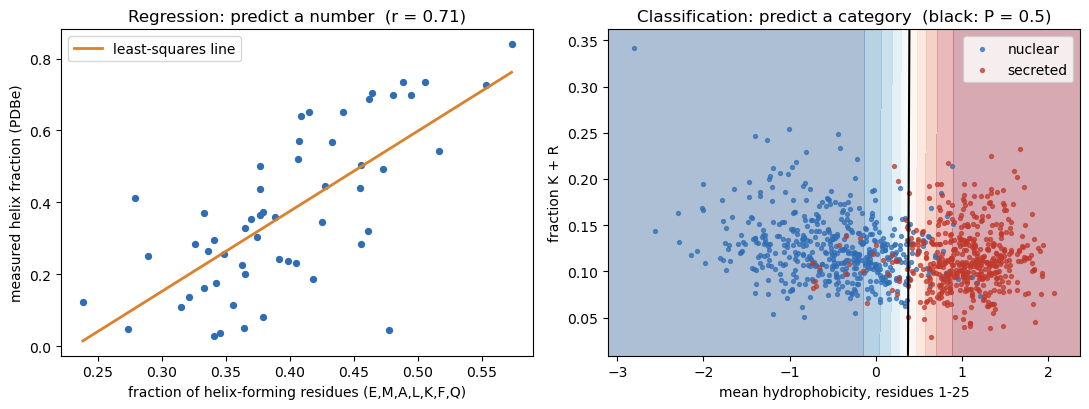

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))

lin = LinearRegression().fit(former_frac.reshape(-1, 1), helix_frac)
xx = np.linspace(former_frac.min(), former_frac.max(), 50)
a1.scatter(former_frac, helix_frac, s=18, color="#2f6db5")
a1.plot(xx, lin.predict(xx.reshape(-1, 1)), color="#d9822b", lw=2, label="least-squares line")
a1.set_xlabel("fraction of helix-forming residues (E,M,A,L,K,F,Q)")
a1.set_ylabel("measured helix fraction (PDBe)")
a1.set_title(f"Regression: predict a number  (r = {pearsonr(former_frac, helix_frac)[0]:.2f})")
a1.legend(loc="upper left")

g1, g2 = np.meshgrid(np.linspace(X2[:, 0].min() - 0.3, X2[:, 0].max() + 0.3, 200),
                     np.linspace(X2[:, 1].min() - 0.02, X2[:, 1].max() + 0.02, 200))
prob = logreg.predict_proba(np.c_[g1.ravel(), g2.ravel()])[:, 1].reshape(g1.shape)
a2.contourf(g1, g2, prob, levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=0.35)
a2.contour(g1, g2, prob, levels=[0.5], colors="k", linewidths=1.5)
a2.scatter(*X2[y2 == 0].T, s=8, color="#2f6db5", label="nuclear", alpha=0.7)
a2.scatter(*X2[y2 == 1].T, s=8, color="#c0392b", label="secreted", alpha=0.7)
a2.set_xlabel("mean hydrophobicity, residues 1-25")
a2.set_ylabel("fraction K + R")
a2.set_title("Classification: predict a category  (black: P = 0.5)")
a2.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"{FIGS}/day08-regression-vs-classification.png", dpi=150, bbox_inches="tight")
plt.show()

The fitted classifier leans almost entirely on N-terminal hydrophobicity.
The K+R weight is small: the two classes overlap heavily on that axis,
and the model learned that from the data.

| | Regression | Classification |
|---|---|---|
| Label | a number | one of $K$ categories |
| Output unit | linear (no activation) | sigmoid (2 classes) / softmax ($K$ classes) |
| Loss (Day 9) | mean squared error | cross-entropy |
| Metrics (Part 2) | RMSE, Pearson $r$, $R^2$ | confusion matrix, precision/recall, F1, MCC, AUROC |

## A running toy example: 3×3 pixel patterns

Magnus Ekman's *Learning Deep Learning* (ch. 2) trains perceptrons to
recognise tiny 3×3 pixel patterns. We reuse the idea as the smallest
possible classification problem: nine inputs (dark = +1, light = −1) and
five classes. Every example is a clean pattern plus Gaussian noise
(σ = 0.8 per pixel). "Cross" deliberately shares its middle row with
"horizontal" and its middle column with "vertical", so some confusions
are expected.

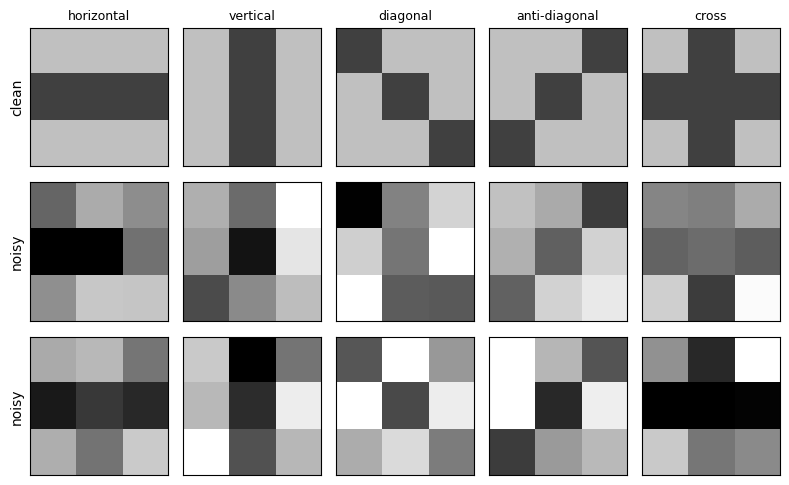

In [6]:
PATTERNS = {
    "horizontal":    [[0, 0, 0], [1, 1, 1], [0, 0, 0]],
    "vertical":      [[0, 1, 0], [0, 1, 0], [0, 1, 0]],
    "diagonal":      [[1, 0, 0], [0, 1, 0], [0, 0, 1]],
    "anti-diagonal": [[0, 0, 1], [0, 1, 0], [1, 0, 0]],
    "cross":         [[0, 1, 0], [1, 1, 1], [0, 1, 0]],
}
PAT_NAMES = list(PATTERNS)
CLEAN = np.array([np.where(np.array(p).flatten() == 1, 1.0, -1.0) for p in PATTERNS.values()])
SIGMA = 0.8

def sample_patterns(n_per_class, rng, sigma=SIGMA):
    y = np.repeat(np.arange(len(PAT_NAMES)), n_per_class)
    X = CLEAN[y] + rng.normal(0, sigma, (len(y), 9))
    return X, y

rng = np.random.RandomState(0)
X_demo, y_demo = sample_patterns(2, rng)
fig, axes = plt.subplots(3, 5, figsize=(8, 5))
for c, name in enumerate(PAT_NAMES):
    axes[0, c].imshow(-CLEAN[c].reshape(3, 3), cmap="gray", vmin=-2, vmax=2)
    axes[0, c].set_title(name, fontsize=9)
    for k in range(2):
        axes[k + 1, c].imshow(-X_demo[y_demo == c][k].reshape(3, 3), cmap="gray", vmin=-2, vmax=2)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("clean"); axes[1, 0].set_ylabel("noisy"); axes[2, 0].set_ylabel("noisy")
plt.tight_layout()
plt.savefig(f"{FIGS}/day08-3x3-patterns.png", dpi=150, bbox_inches="tight")
plt.show()

# Part 2 — Data and evaluation

## Training, validation and test sets, on the 3×3 problem

- **Training set**: used to fit the weights.
- **Validation set**: used to make choices (here: how many epochs to
  train) without touching the test set.
- **Test set**: used *once*, at the end, to report the final number.

The classifier is five Day-6 perceptrons, one per pattern, each trained
with the perceptron rule to output +1 for its own pattern and −1 for the
rest ("one-vs-rest"). The predicted class is the perceptron with the
highest score $z$. There is no hidden layer, so no backpropagation is
needed.

In [7]:
rng = np.random.RandomState(1)
X_tr, y_tr = sample_patterns(20, rng)    # 100 training examples
X_va, y_va = sample_patterns(20, rng)    # 100 validation examples
X_te, y_te = sample_patterns(40, rng)    # 200 test examples
add_bias = lambda X: np.c_[np.ones(len(X)), X]

def train_one_vs_rest(X, y, epochs, eta=0.1, seed=0):
    r = np.random.RandomState(seed)
    W = r.uniform(-0.5, 0.5, (len(PAT_NAMES), 10))
    Xb = add_bias(X)
    for _ in range(epochs):
        for i in r.permutation(len(Xb)):
            for c in range(len(PAT_NAMES)):
                target = 1 if y[i] == c else -1
                if np.sign(W[c] @ Xb[i]) != target:
                    W[c] += eta * target * Xb[i]       # Day 6's perceptron update
    return W

scores = lambda W, X: add_bias(X) @ W.T
predict = lambda W, X: scores(W, X).argmax(axis=1)

print("epochs   train acc   validation acc")
val_acc = {}
for epochs in [1, 2, 5, 10, 20, 50]:
    W = train_one_vs_rest(X_tr, y_tr, epochs)
    val_acc[epochs] = (predict(W, X_va) == y_va).mean()
    print(f"{epochs:6d}   {(predict(W, X_tr) == y_tr).mean():9.3f}   {val_acc[epochs]:14.3f}")
best_epochs = max(val_acc, key=val_acc.get)
W_pat = train_one_vs_rest(X_tr, y_tr, best_epochs)
test_pred = predict(W_pat, X_te)
print(f"\nchosen on validation: {best_epochs} epochs")
print(f"test accuracy, measured once: {(test_pred == y_te).mean():.3f}")

epochs   train acc   validation acc
     1       0.890            0.840
     2       0.880            0.900
     5       0.940            0.900
    10       0.930            0.890
    20       0.900            0.880
    50       0.950            0.900

chosen on validation: 2 epochs
test accuracy, measured once: 0.895


## Evaluating a classifier

Accuracy alone hides *which* mistakes are made. The **confusion matrix**
(rows = true class, columns = predicted class) shows them. For each
class $c$, treated as "positive" against the rest:

$$
\text{precision} = \frac{TP}{TP+FP} \qquad
\text{recall} = \frac{TP}{TP+FN} \qquad
F_1 = \frac{2\cdot\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}
$$

$$
\text{MCC} = \frac{TP\cdot TN - FP\cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
$$

In [8]:
cm = confusion_matrix(y_te, test_pred)
print("confusion matrix (rows = true, columns = predicted):")
print(" " * 15 + " ".join(f"{n[:6]:>6s}" for n in PAT_NAMES))
for name, row in zip(PAT_NAMES, cm):
    print(f"{name:>14s} " + " ".join(f"{v:6d}" for v in row))

prec, rec, f1, _ = precision_recall_fscore_support(y_te, test_pred, zero_division=0)
print("\nper class:        precision  recall   F1     MCC (class vs rest)")
for c, name in enumerate(PAT_NAMES):
    mcc_c = matthews_corrcoef(y_te == c, test_pred == c)
    print(f"{name:>14s}   {prec[c]:9.2f}  {rec[c]:6.2f}  {f1[c]:5.2f}  {mcc_c:6.2f}")
print(f"\nmulti-class MCC: {matthews_corrcoef(y_te, test_pred):.3f}")

confusion matrix (rows = true, columns = predicted):
               horizo vertic diagon anti-d  cross
    horizontal     36      0      0      0      4
      vertical      0     38      0      0      2
      diagonal      0      1     39      0      0
 anti-diagonal      2      2      0     36      0
         cross      1      9      0      0     30

per class:        precision  recall   F1     MCC (class vs rest)
    horizontal        0.92    0.90   0.91    0.89
      vertical        0.76    0.95   0.84    0.81
      diagonal        1.00    0.97   0.99    0.98
 anti-diagonal        1.00    0.90   0.95    0.94
         cross        0.83    0.75   0.79    0.74

multi-class MCC: 0.871


**ROC curve.** A classifier that outputs a *score* needs a threshold to
turn it into yes/no. Sliding the threshold trades false positives
against false negatives; the ROC curve plots the true-positive rate
against the false-positive rate for every threshold. Below: the "cross"
perceptron's score, cross vs. everything else. AUROC is 0.5 for random
guessing and 1.0 for a perfect ranking.

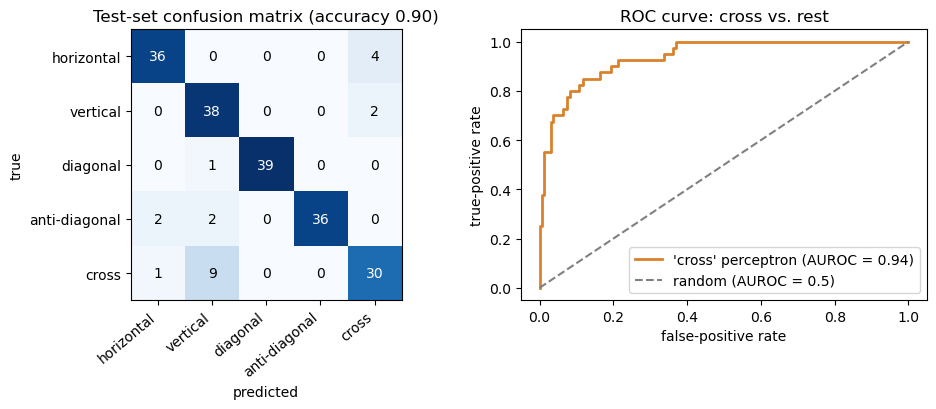

AUROC, cross vs rest: 0.938


In [9]:
c = PAT_NAMES.index("cross")
fpr, tpr, thr = roc_curve(y_te == c, scores(W_pat, X_te)[:, c])
auc_cross = roc_auc_score(y_te == c, scores(W_pat, X_te)[:, c])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4.2))
im = a1.imshow(cm, cmap="Blues")
a1.set_xticks(range(5)); a1.set_xticklabels(PAT_NAMES, rotation=40, ha="right")
a1.set_yticks(range(5)); a1.set_yticklabels(PAT_NAMES)
for i in range(5):
    for j in range(5):
        a1.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > 20 else "black")
a1.set_xlabel("predicted"); a1.set_ylabel("true")
a1.set_title(f"Test-set confusion matrix (accuracy {(test_pred == y_te).mean():.2f})")
a2.plot(fpr, tpr, color="#d9822b", lw=2, label=f"'cross' perceptron (AUROC = {auc_cross:.2f})")
a2.plot([0, 1], [0, 1], "--", color="grey", label="random (AUROC = 0.5)")
a2.set_xlabel("false-positive rate"); a2.set_ylabel("true-positive rate")
a2.set_title("ROC curve: cross vs. rest"); a2.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIGS}/day08-3x3-evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"AUROC, cross vs rest: {auc_cross:.3f}")

## Evaluating a regression model

Regression predictions are not right or wrong, only more or less off.
The standard numbers, computed on held-out proteins from the helix
example:

- **RMSE** $=\sqrt{\frac1n\sum(y_i-\hat y_i)^2}$, in the target's own units;
- **Pearson $r$** between predicted and true values;
- **$R^2$** $= 1 - \frac{\sum (y_i-\hat y_i)^2}{\sum (y_i-\bar y)^2}$, the
  fraction of variance explained (0 = no better than predicting the mean).

In [10]:
xh_tr, xh_te, yh_tr, yh_te = train_test_split(former_frac.reshape(-1, 1), helix_frac, test_size=0.25, random_state=0)
lin = LinearRegression().fit(xh_tr, yh_tr)
pred_te = lin.predict(xh_te)
rmse = np.sqrt(mean_squared_error(yh_te, pred_te))
baseline_rmse = np.sqrt(mean_squared_error(yh_te, np.full_like(yh_te, yh_tr.mean())))
print(f"{len(yh_tr)} training / {len(yh_te)} test proteins")
print(f"test RMSE: {rmse:.3f}   (predicting the training mean for everything: {baseline_rmse:.3f})")
print(f"test Pearson r: {pearsonr(yh_te, pred_te)[0]:.3f}")
print(f"test R^2: {r2_score(yh_te, pred_te):.3f}")

41 training / 14 test proteins
test RMSE: 0.159   (predicting the training mean for everything: 0.234)
test Pearson r: 0.760
test R^2: 0.526


## Real data: the subcellular-localization dataset

Mitochondrion is the smallest class. First, a look at what **class
imbalance** does to accuracy, using all the unambiguous entries without
balancing:

In [11]:
counts = np.array([len(entries_by_class[c]) for c in CLASS_NAMES])
y_all = np.repeat(np.arange(5), counts)
majority = counts.argmax()
always_majority = np.full_like(y_all, majority)
print("class sizes:", dict(zip(CLASS_NAMES, counts.tolist())))
print(f"'always predict {CLASS_NAMES[majority]}': accuracy = {(always_majority == y_all).mean():.3f}, "
      f"MCC = {matthews_corrcoef(y_all, always_majority):.3f}")
print(f"'always predict Mitochondrion': accuracy = {(y_all == 2).mean():.3f}")

class sizes: {'Cytoplasm': 424, 'Nucleus': 497, 'Mitochondrion': 140, 'Secreted': 488, 'Cell membrane': 338}
'always predict Nucleus': accuracy = 0.263, MCC = 0.000
'always predict Mitochondrion': accuracy = 0.074


A classifier that has learned nothing still scores well above the 20%
you might expect for five classes, while MCC correctly reports 0. From
here on the classes are balanced to the size of the smallest one:

In [12]:
N_PER_CLASS = counts.min()
rng = np.random.RandomState(0)
balanced_accs, balanced_seqs, balanced_labels = [], [], []
for class_idx, class_name in enumerate(CLASS_NAMES):
    pool = entries_by_class[class_name]
    for i in rng.choice(len(pool), N_PER_CLASS, replace=False):
        balanced_accs.append(pool[i][0])
        balanced_seqs.append(pool[i][1])
        balanced_labels.append(class_idx)
print("balanced dataset:", len(balanced_seqs), "sequences,", N_PER_CLASS, "per class")

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
SEQ_LEN = 150   # localization signals are mostly N-terminal

def one_hot_encode(sequence, length=SEQ_LEN):
    encoded = np.zeros((length, len(AMINO_ACIDS)), dtype=np.float32)
    for position, residue in enumerate(sequence[:length]):
        if residue in AA_TO_INDEX:
            encoded[position, AA_TO_INDEX[residue]] = 1.0
    return encoded.flatten()

X = np.stack([one_hot_encode(s) for s in balanced_seqs])
y = np.array(balanced_labels)
print("X shape:", X.shape, " (sequences x 150 positions x 20 amino acids, flattened)")

balanced dataset: 700 sequences, 140 per class
X shape: (700, 3000)  (sequences x 150 positions x 20 amino acids, flattened)


### How much can you trust a single split?

A fast baseline (logistic regression on the one-hot features), refitted
on ten different random stratified 70/15/15 splits:

In [13]:
idx_all = np.arange(len(y))
random_split_acc = []
for seed in range(10):
    tr, tmp = train_test_split(idx_all, test_size=0.30, stratify=y, random_state=seed)
    va, te = train_test_split(tmp, test_size=0.5, stratify=y[tmp], random_state=seed)
    clf = LogisticRegression(max_iter=2000, random_state=0).fit(X[tr], y[tr])
    random_split_acc.append(clf.score(X[va], y[va]))
random_split_acc = np.array(random_split_acc)
print("validation accuracy per split:", np.round(random_split_acc, 3))
print(f"mean = {random_split_acc.mean():.3f}, std = {random_split_acc.std():.3f}, "
      f"range = [{random_split_acc.min():.3f}, {random_split_acc.max():.3f}]")

validation accuracy per split: [0.581 0.571 0.552 0.6   0.571 0.505 0.533 0.552 0.61  0.533]
mean = 0.561, std = 0.031, range = [0.505, 0.610]


### Cross-validation

**k-fold cross-validation** uses every example for validation exactly
once: split into $k$ stratified folds, train on $k-1$, validate on the
remaining one, and average.

In [14]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
fold_acc = []
for fold, (tr, va) in enumerate(kfold.split(X, y)):
    clf = LogisticRegression(max_iter=2000, random_state=0).fit(X[tr], y[tr])
    fold_acc.append(clf.score(X[va], y[va]))
    print(f"fold {fold}: {len(tr)} train / {len(va)} val -> accuracy {fold_acc[-1]:.3f}")
print(f"5-fold CV: mean = {np.mean(fold_acc):.3f}, std = {np.std(fold_acc):.3f}")

fold 0: 560 train / 140 val -> accuracy 0.600


fold 1: 560 train / 140 val -> accuracy 0.471


fold 2: 560 train / 140 val -> accuracy 0.571
fold 3: 560 train / 140 val -> accuracy 0.536


fold 4: 560 train / 140 val -> accuracy 0.521
5-fold CV: mean = 0.540, std = 0.044


## The biological trap: homologs on both sides of the split

A random split treats every protein as independent. Proteins are not
independent: they come in **families** of homologs (Day 4) that share
sequence *and* usually function and localization. If one family member
is in the training set and another in the test set, the model can score
well by recognising the family, without learning anything about
localization signals. The test then measures memorisation rather than
generalisation to new kinds of proteins.

The standard remedy is **homology partitioning**: cluster the sequences
by identity, then assign whole clusters to training, validation or
test. Here we cluster at 30% identity with **MMseqs2** (a fast
alternative to all-against-all BLAST). If `mmseqs` isn't installed (e.g.
on Colab), the notebook loads the precomputed clustering of the same 700
proteins from the course repository.

In [15]:
CLUSTER_URL = "https://raw.githubusercontent.com/ElofssonLab/kb8029-book/main/notebooks/data/day08-subcell-mmseqs-30.tsv"
LOCAL_TSV = "data/day08-subcell-mmseqs-30.tsv"

def mmseqs_clusters(accs, seqs, min_seq_id=0.3):
    tmp = tempfile.mkdtemp()
    with open(f"{tmp}/in.fasta", "w") as f:
        for a, s in zip(accs, seqs):
            f.write(f">{a}\n{s}\n")
    subprocess.run(["mmseqs", "easy-cluster", f"{tmp}/in.fasta", f"{tmp}/clu", f"{tmp}/work",
                    "--min-seq-id", str(min_seq_id), "-c", "0.5", "-v", "1"],
                   check=True, stdout=subprocess.DEVNULL)
    pairs = [line.split("\t") for line in open(f"{tmp}/clu_cluster.tsv").read().split("\n") if line]
    shutil.rmtree(tmp)
    return {member: rep for rep, member in pairs}

def load_precomputed_clusters():
    text = open(LOCAL_TSV).read() if os.path.exists(LOCAL_TSV) else requests.get(CLUSTER_URL, timeout=30).text
    pairs = [line.split("\t") for line in text.strip().split("\n")[1:]]
    return {member: rep for rep, member in pairs}

if shutil.which("mmseqs"):
    member_to_rep = mmseqs_clusters(balanced_accs, balanced_seqs)
    print("clustered with local MMseqs2 (30% identity, 50% coverage)")
else:
    member_to_rep = load_precomputed_clusters()
    print("mmseqs not found -- loaded the precomputed MMseqs2 clustering")

# proteins missing from the clustering (e.g. if UniProt changed) become their own cluster
reps = [member_to_rep.get(a, a) for a in balanced_accs]
rep_ids = {r: i for i, r in enumerate(sorted(set(reps)))}
groups = np.array([rep_ids[r] for r in reps])
sizes = np.bincount(groups)
print(f"{len(y)} proteins -> {len(sizes)} clusters; "
      f"{(sizes > 1).sum()} clusters have more than one member ({sizes[sizes > 1].sum()} proteins), largest has {sizes.max()}")

clustered with local MMseqs2 (30% identity, 50% coverage)
700 proteins -> 551 clusters; 75 clusters have more than one member (224 proteins), largest has 11


How often does a random split put a protein's homolog in the training
set, and what does that do to the baseline's accuracy? We pool the
validation predictions from the same ten random splits as above:

In [16]:
with_homolog, without_homolog, leak_frac = [], [], []
for seed in range(10):
    tr, tmp = train_test_split(idx_all, test_size=0.30, stratify=y, random_state=seed)
    va, te = train_test_split(tmp, test_size=0.5, stratify=y[tmp], random_state=seed)
    pred = LogisticRegression(max_iter=2000, random_state=0).fit(X[tr], y[tr]).predict(X[va])
    train_groups = set(groups[tr])
    has = np.array([groups[i] in train_groups for i in va])
    leak_frac.append(has.mean())
    with_homolog += list(pred[has] == y[va][has])
    without_homolog += list(pred[~has] == y[va][~has])
print(f"validation proteins with a >=30%-identity homolog in the training set: {np.mean(leak_frac):.1%}")
print(f"accuracy on those:      {np.mean(with_homolog):.3f}  (n = {len(with_homolog)})")
print(f"accuracy on the rest:   {np.mean(without_homolog):.3f}  (n = {len(without_homolog)})")

validation proteins with a >=30%-identity homolog in the training set: 31.3%
accuracy on those:      0.675  (n = 329)
accuracy on the rest:   0.509  (n = 721)


Now a **homology-aware split**: clusters are assigned whole, one at a
time in random order, to whichever of train/validation/test is furthest
below its 70/15/15 share of that cluster's classes. No cluster crosses
the split. The function is deterministic and uses plain NumPy, so Days 9
and 10 can copy it and get exactly the same split.

In [17]:
def homology_split(y, groups, fractions=(0.70, 0.15, 0.15), seed=0):
    '''Assign whole clusters, in random order, to train/val/test: each cluster
    goes to the split furthest below its target share of that cluster's
    classes (ties broken at random). Returns three index arrays.'''
    rng = np.random.RandomState(seed)
    n_classes = y.max() + 1
    target = np.outer(fractions, np.bincount(y, minlength=n_classes))   # (3 splits, n_classes)
    have = np.zeros_like(target)
    assignment = {}
    for g in rng.permutation(np.unique(groups)):
        cls_counts = np.bincount(y[groups == g], minlength=n_classes)
        deficit = ((target - have) * (cls_counts > 0)).sum(axis=1) / target.sum(axis=1)
        best = np.flatnonzero(deficit == deficit.max())
        split = int(rng.choice(best))
        assignment[g] = split
        have[split] += cls_counts
    split_of = np.array([assignment[g] for g in groups])
    return [np.where(split_of == k)[0] for k in range(3)]

tr_h, va_h, te_h = homology_split(y, groups)
assert not (set(groups[tr_h]) & set(groups[va_h]) or set(groups[tr_h]) & set(groups[te_h]) or set(groups[va_h]) & set(groups[te_h]))
print(f"homology-aware split: train {len(tr_h)} / val {len(va_h)} / test {len(te_h)}")
for name, ix in [("train", tr_h), ("val", va_h), ("test", te_h)]:
    print(f"  {name:5s} per class: {np.bincount(y[ix], minlength=5).tolist()}")

homology-aware split: train 486 / val 105 / test 109
  train per class: [98, 98, 98, 94, 98]
  val   per class: [21, 21, 21, 21, 21]
  test  per class: [21, 21, 21, 25, 21]


Is the baseline worse on homology-aware splits? One split is too noisy to
tell (the std across random splits above is about 0.03), so compare ten
of each, pooling validation and test accuracy:

In [18]:
def baseline_acc(tr, va, te):
    clf = LogisticRegression(max_iter=2000, random_state=0).fit(X[tr], y[tr])
    return (clf.score(X[va], y[va]) + clf.score(X[te], y[te])) / 2

random_acc, homology_acc = [], []
for seed in range(10):
    tr, tmp = train_test_split(idx_all, test_size=0.30, stratify=y, random_state=seed)
    va, te = train_test_split(tmp, test_size=0.5, stratify=y[tmp], random_state=seed)
    random_acc.append(baseline_acc(tr, va, te))
    homology_acc.append(baseline_acc(*homology_split(y, groups, seed=seed)))
print(f"random splits:          mean accuracy {np.mean(random_acc):.3f}  (std {np.std(random_acc):.3f})")
print(f"homology-aware splits:  mean accuracy {np.mean(homology_acc):.3f}  (std {np.std(homology_acc):.3f})")

random splits:          mean accuracy 0.553  (std 0.019)
homology-aware splits:  mean accuracy 0.536  (std 0.026)


The overall drop is small here, because 476 of the 700 proteins (the
singleton clusters) have no
homolog in the dataset at all. What matters is the per-protein effect
above: a protein with a homolog in training is classified correctly far
more often. In more redundant datasets (a whole proteome, or the PDB,
where some families have thousands of members) the gap between random
and homology-aware evaluation becomes much larger.

This homology-aware split is the one used from here on, and by Day 9 and
Day 10's notebooks. Numbers measured on it are lower, and more honest.

In [19]:
X_train, y_train = X[tr_h], y[tr_h]
X_val, y_val = X[va_h], y[va_h]
X_test, y_test = X[te_h], y[te_h]
print(f"train: {len(X_train)}   val: {len(X_val)}   test: {len(X_test)}")

train: 486   val: 105   test: 109


# Part 3 — From neurons to networks

## Smooth activation functions

Day 6's perceptron used a step function. Its derivative is zero almost
everywhere, which gives gradient descent nothing to follow. Networks
replace it with smooth functions. You have already met one: the sigmoid
of logistic regression in Part 1.

$$
\sigma(z) = \frac{1}{1+e^{-z}} \qquad \tanh(z) = 2\sigma(2z) - 1 \qquad \text{ReLU}(z) = \max(0, z)
$$

(Their derivatives, and why that matters for deep networks, are Day 9's
topic.)

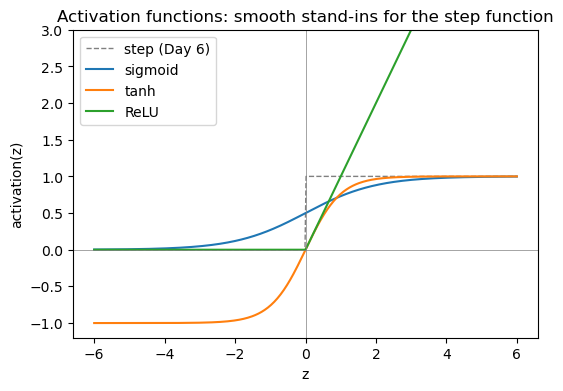

In [20]:
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
def relu(x): return np.maximum(0, x)

x = np.linspace(-6, 6, 400)
plt.figure(figsize=(6, 4))
plt.plot(x, np.where(x > 0, 1.0, 0.0), color="grey", lw=1, ls="--", label="step (Day 6)")
plt.plot(x, sigmoid(x), label="sigmoid")
plt.plot(x, np.tanh(x), label="tanh")
plt.plot(x, relu(x), label="ReLU")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.ylim(-1.2, 3)
plt.legend()
plt.title("Activation functions: smooth stand-ins for the step function")
plt.xlabel("z"); plt.ylabel("activation(z)")
plt.savefig(f"{FIGS}/day08-activation-functions.png", dpi=150, bbox_inches="tight")
plt.show()

## From one output to many: softmax

The 3×3 classifier produces five scores and picks the largest.
**Softmax** turns $K$ scores (logits) into $K$ probabilities that sum to 1:

$$
\text{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}
$$

Applied to the five perceptron scores for one noisy test pattern:

In [21]:
i = int(np.where((test_pred != y_te))[0][0])     # the first misclassified test example
z = scores(W_pat, X_te[i:i+1])[0]
p = np.exp(z - z.max()); p /= p.sum()
print(f"true class: {PAT_NAMES[y_te[i]]}")
print(f"{'class':>14s}  {'score z':>8s}  {'softmax':>8s}")
for name, zi, pi in zip(PAT_NAMES, z, p):
    print(f"{name:>14s}  {zi:8.2f}  {pi:8.3f}")
print("sum of probabilities:", round(p.sum(), 6))

true class: horizontal
         class   score z   softmax
    horizontal     -2.19     0.059
      vertical     -0.80     0.235
      diagonal     -2.35     0.050
 anti-diagonal     -2.61     0.039
         cross      0.16     0.618
sum of probabilities: 1.0


Softmax never changes *which* class wins, but it shows how close the
decision was. (Perceptron scores were not trained to be probabilities,
so these numbers are only illustrative. Day 9's cross-entropy loss
trains the scores so that softmax gives calibrated probabilities.)

## Practical PyTorch: models as classes

A PyTorch model is a class inheriting from `nn.Module`: its layers are
attributes created in `__init__`, and `forward()` says how input becomes
output. The 3×3 classifier is exactly one `nn.Linear(9, 5)` layer.
Copying the perceptron weights into it gives identical predictions:

In [22]:
class PatternClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(9, 5)      # 5 outputs, each a weighted sum of 9 pixels + bias

    def forward(self, x):
        return self.linear(x)              # raw scores (logits)

pat_model = PatternClassifier()
with torch.no_grad():
    pat_model.linear.bias.copy_(torch.tensor(W_pat[:, 0]))
    pat_model.linear.weight.copy_(torch.tensor(W_pat[:, 1:]))
    torch_pred = pat_model(torch.tensor(X_te, dtype=torch.float32)).argmax(dim=1).numpy()
print("parameters:", sum(p.numel() for p in pat_model.parameters()), "(5 x 9 weights + 5 biases)")
print("identical predictions to the NumPy perceptrons:", bool((torch_pred == test_pred).all()))

parameters: 50 (5 x 9 weights + 5 biases)
identical predictions to the NumPy perceptrons: True


### The localization network, defined but not trained

The same pattern, bigger: 3000 inputs, one hidden layer of 64 ReLU units,
and 5 output logits. There is no explicit softmax, because Day 9's
`nn.CrossEntropyLoss` applies it internally.

In [23]:
class SubcellularLocalizationClassifier(nn.Module):
    def __init__(self, input_dim=SEQ_LEN * len(AMINO_ACIDS), hidden_dim=64, n_classes=5, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.net(x)  # raw logits, shape (batch, n_classes)


model = SubcellularLocalizationClassifier()
print(model)
print("total trainable parameters:", sum(p.numel() for p in model.parameters()))

SubcellularLocalizationClassifier(
  (net): Sequential(
    (0): Linear(in_features=3000, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)
total trainable parameters: 192389


One forward pass on the validation set checks that the shapes work.
**The weights are still random.** The metrics show what "no better than
chance" looks like, and give the baseline Day 9 compares against.

In [24]:
X_val_t = torch.tensor(X_val, dtype=torch.float32)
with torch.no_grad():
    logits = model(X_val_t)
print("input shape: ", tuple(X_val_t.shape))
print("output shape:", tuple(logits.shape))

predicted = logits.argmax(dim=1).numpy()
probs = torch.softmax(logits, dim=1).numpy()
_, _, f1_macro, _ = precision_recall_fscore_support(y_val, predicted, average="macro", zero_division=0)
print(f"\naccuracy:    {(predicted == y_val).mean():.3f}   (chance: 0.20)")
print(f"macro F1:    {f1_macro:.3f}")
print(f"MCC:         {matthews_corrcoef(y_val, predicted):.3f}")
print(f"macro AUROC: {roc_auc_score(y_val, probs, multi_class='ovr'):.3f}")
print("confusion matrix:\n", confusion_matrix(y_val, predicted))

input shape:  (105, 3000)
output shape: (105, 5)

accuracy:    0.181   (chance: 0.20)
macro F1:    0.124
MCC:         -0.027
macro AUROC: 0.474
confusion matrix:
 [[ 1 14  4  2  0]
 [ 4 14  3  0  0]
 [ 6 12  3  0  0]
 [ 4 11  5  1  0]
 [ 5  8  5  3  0]]


## Try it yourself

- Change `SIGMA` in the 3×3 section (e.g. 0.5 or 1.2), re-run, and watch
  test accuracy and the confusion matrix. Which pairs of patterns get
  confused, and why?
- Replace "cross" with a pattern that shares fewer pixels with the others
  and check whether the confusions go away.
- In the homology section, change `min_seq_id` to 0.5 (needs a local
  `mmseqs`). How much of the leakage remains?